# 06 - FLAML Optimization and Evaluation

## Why FLAML exists
FLAML performs cost-aware automated model search and hyperparameter optimization.

## Strengths
- Time-budget aware optimization
- Fast candidate prioritization

## Weaknesses
- Lower interpretability of search logic vs fully manual tuning


## Definition
FLAML performs budget-aware model and hyperparameter search for better cost-performance tradeoffs.

## Theory
This section explains the statistical or ML theory behind the technique and why it is useful in credit recovery operations.

## Mathematical Intuition
We translate the idea into score/probability/ranking logic so each metric can be interpreted quantitatively.

## Financial Intuition
We connect the method to borrower affordability, delinquency severity, collateral protection, and expected recoverable cashflows.

## Business Impact
We explain what this enables for collection managers, risk teams, and executives.

## Real-World Example
With fixed model runtime budget, FLAML can discover stronger configurations for written-off detection.

## Visual Explanation
Charts in this notebook show how model/segment behavior changes across borrower groups.

## Code Explanation
Every code cell below is paired with interpretation so beginners can connect implementation details to business outcomes.

## Interpretation of Results
We summarize what changed, why it matters, and how to act on it.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.loan_recovery import (
    DATA_PATH,
    FIGURES_DIR,
    MODELS_DIR,
    TABLES_DIR,
    REPORTS_DIR,
    LoanDataLoader,
    FeatureEngineer,
    LoanEDA,
    BorrowerSegmenter,
    ModelTrainer,
    ModelEvaluator,
    RecoveryStrategyEngine,
    ModelExplainer,
    DashboardBuilder,
    LazyPredictBenchmark,
    PyCaretWorkflow,
    FLAMLOptimizer,
    SmartLoanRecoveryPipeline,
    load_model,
)

sns.set_theme(style="whitegrid")


In [2]:
def ensure_pipeline_artifacts() -> None:
    required = [
        TABLES_DIR / "manual_model_leaderboard.csv",
        TABLES_DIR / "feature_enriched_data.csv",
        MODELS_DIR / "best_manual_model.joblib",
    ]
    if not all(path.exists() for path in required):
        pipeline = SmartLoanRecoveryPipeline(data_path=DATA_PATH, random_state=42)
        pipeline.run()

ensure_pipeline_artifacts()


In [3]:
df = LoanDataLoader(DATA_PATH).load()
fe = FeatureEngineer()
enriched = fe.engineer(df)
split = fe.train_test_split(enriched, target_col="Recovery_Status", drop_cols=["Borrower_ID"])

x_train = pd.get_dummies(split.x_train)
x_test = pd.get_dummies(split.x_test)
x_train, x_test = x_train.align(x_test, axis=1, join="left", fill_value=0)

optimizer = FLAMLOptimizer(time_budget=20, random_state=42)
flaml_out = optimizer.run(x_train, split.y_train, x_test, split.y_test)
flaml_out


FLAMLArtifacts(estimator_name='rf', best_config={'n_estimators': 8, 'max_features': 0.11056432815596398, 'max_leaves': 4, 'criterion': 'entropy'}, best_loss=0.6246543394969182, metrics={'accuracy': 0.47, 'precision_weighted': 0.4363, 'recall_weighted': 0.47, 'f1_weighted': 0.4378, 'roc_auc_ovr': 0.5607}, model=RandomForestEstimator(_estimator_type='classifier', criterion='entropy',
                      max_features=0.11056432815596398, max_leaf_nodes=4,
                      n_estimators=8, n_jobs=-1, random_state=12032022,
                      task=<flaml.automl.task.generic_task.GenericTask object at 0x79468ef37950>,
                      verbose=0))

In [4]:
manual = pd.read_csv(TABLES_DIR / "manual_model_leaderboard.csv")
manual_best = manual.iloc[0]

comparison = pd.DataFrame(
    [
        {
            "workflow": "Manual Best",
            "model": manual_best["model"],
            "accuracy": manual_best["accuracy"],
            "f1_weighted": manual_best["f1_weighted"],
            "roc_auc_ovr": manual_best["roc_auc_ovr"],
        },
        {
            "workflow": "FLAML",
            "model": flaml_out.estimator_name,
            "accuracy": flaml_out.metrics["accuracy"],
            "f1_weighted": flaml_out.metrics["f1_weighted"],
            "roc_auc_ovr": flaml_out.metrics["roc_auc_ovr"],
        },
    ]
)
display(comparison)


,workflow,model,accuracy,f1_weighted,roc_auc_ovr
0,Manual Best,SVM,0.44,0.4352,0.5159
1,FLAML,rf,0.47,0.4378,0.5607


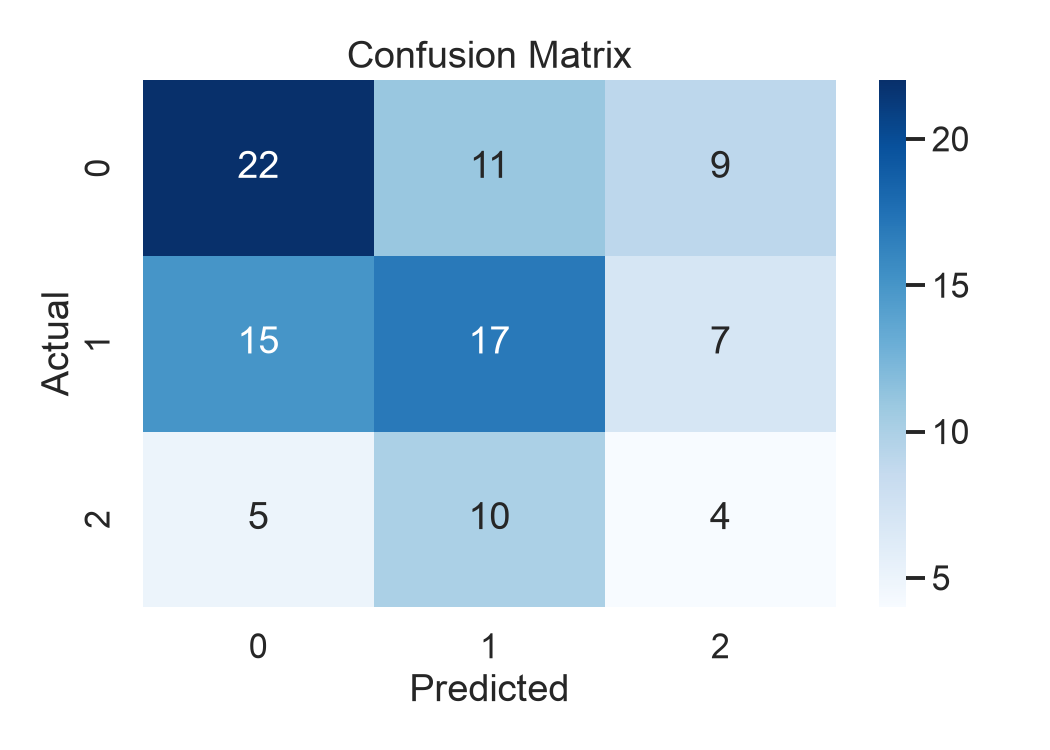

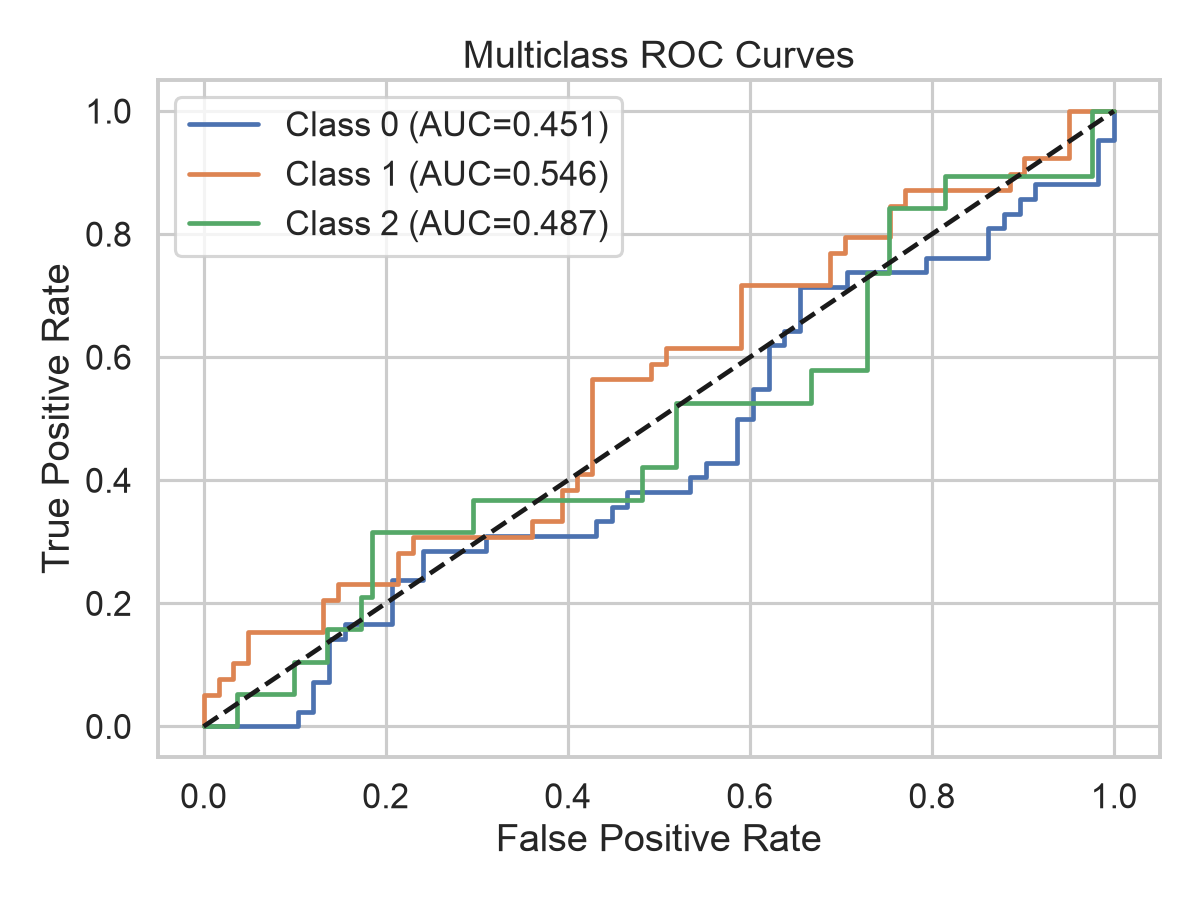

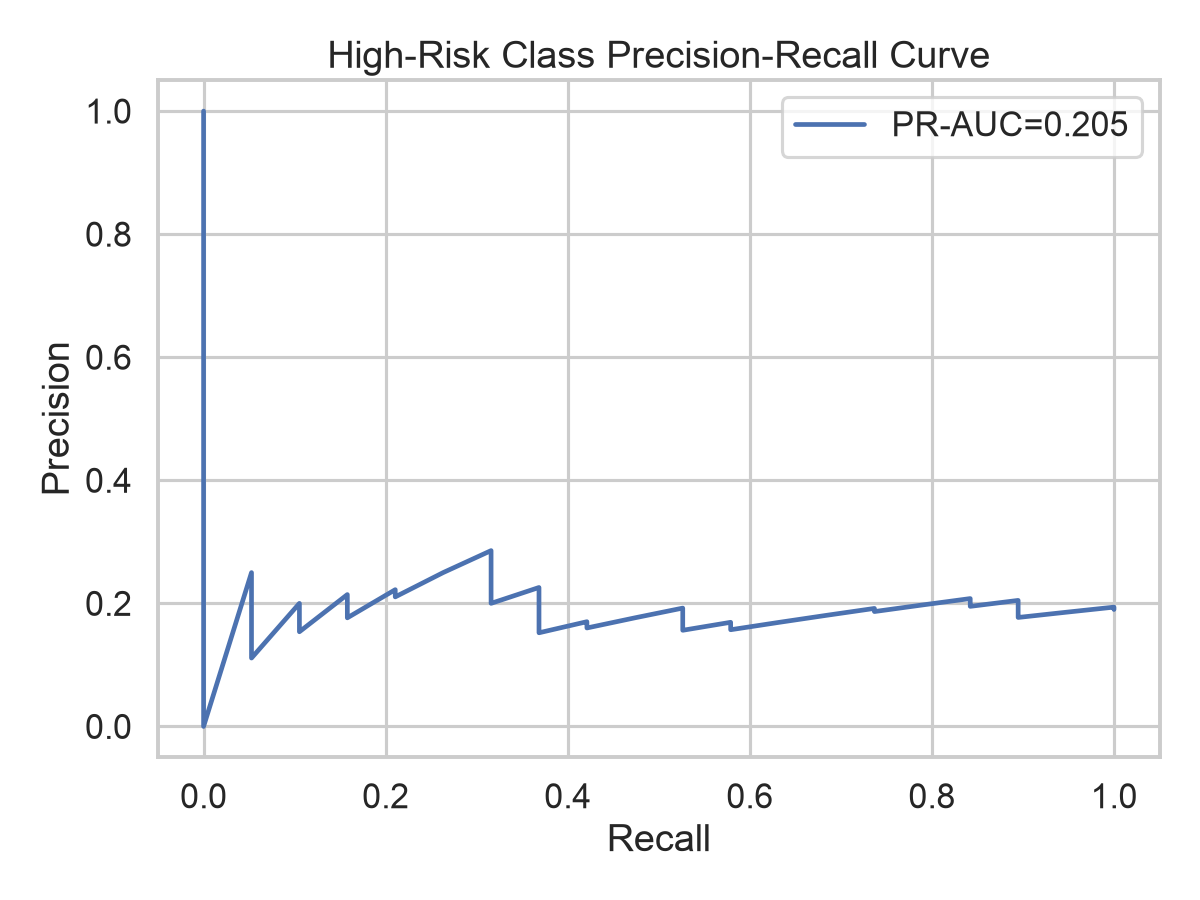

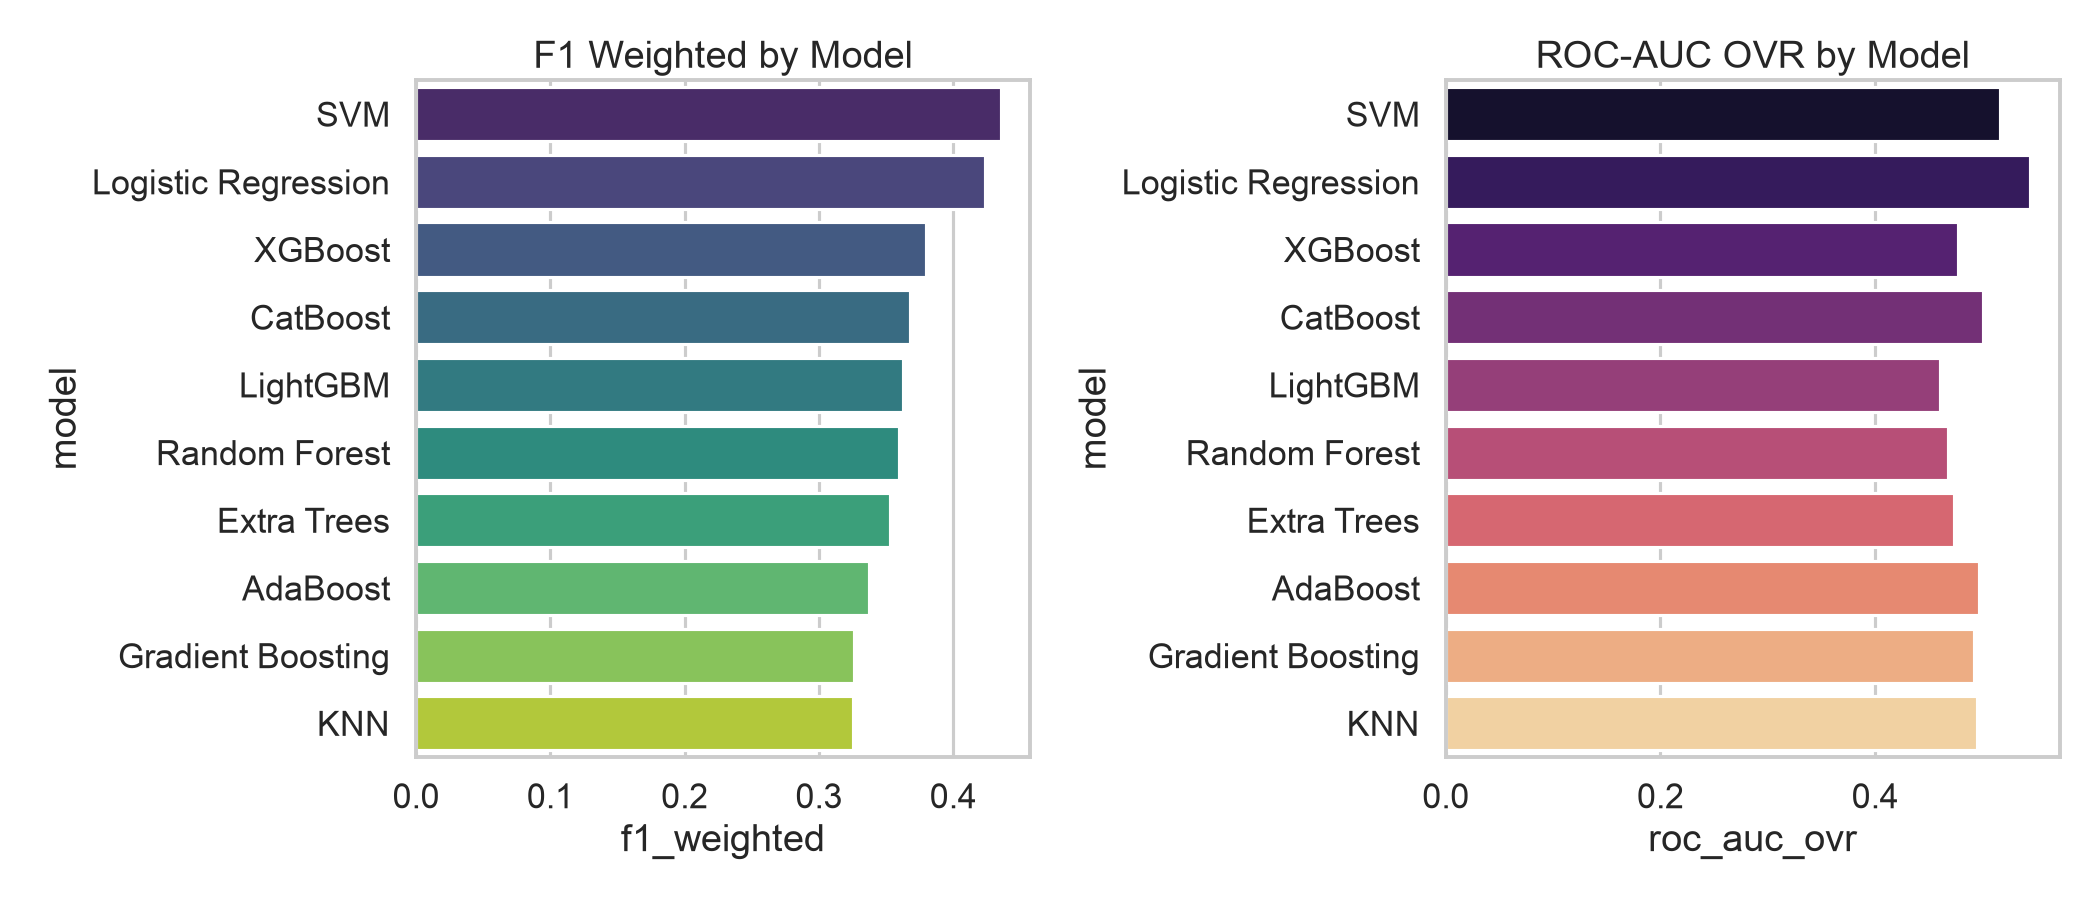

In [5]:
from IPython.display import Image, display
for image_path in [
    FIGURES_DIR / "confusion_matrix.png",
    FIGURES_DIR / "roc_curves.png",
    FIGURES_DIR / "pr_curve_high_risk.png",
    FIGURES_DIR / "model_comparison.png",
]:
    display(Image(filename=str(image_path)))


## Evaluation Notes
Always report both statistical metrics and business metrics (recovery rate, high-risk detection, and cost impact).
